## Exoplanet Lightcurve Preparation Pipeline
* Supports CNN and Bayesian input
*  Includes robust batching, threading, checkpointing
*  Optional transit injection (Levi I think made a comment on this so I addded it?)
*  Automatic BLS/SNR/feature extraction for classical models

In [1]:
# imports
import os
import kagglehub
import pandas as pd
import numpy as np
from lightkurve import search_lightcurve, LightCurve
from scipy.interpolate import interp1d
from astropy.timeseries import BoxLeastSquares
from tqdm import tqdm
import concurrent.futures
import glob

# parameters
OUTDIR = "./cnn_ready_dataset"
if not os.path.exists(OUTDIR):
    os.makedirs(OUTDIR)
samples = 500                # samples to get
batch_size = 50              # how many stars per batch (checkpointed)
workers = 4                  # thread count for parallelism
CNN_input_size = 2000        # input size for the CNN
single_quarter = True        # True = Fast (Minutes), False = Slow (Hours)
inject_transit = False       # Set True to inject a simulated (box) transit into all negatives

/opt/anaconda3/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
# 1) downloading the dataset as CSVs
path = kagglehub.dataset_download("vijayveersingh/kepler-and-tess-exoplanet-data")
dfs = {}
for file in os.listdir(path):
    if file.endswith(".csv"):
        dfs[file] = pd.read_csv(os.path.join(path, file), comment='#')
        print("Loaded:", file)
print("\nFiles loaded:", list(dfs.keys()))

Loaded: q1_q17_dr25_koifpp_2025.02.03_06.14.34.csv
Loaded: PS_2025.02.03_05.09.36.csv
Loaded: TOI_2025.02.03_06.18.31.csv
Loaded: keplerstellar_2025.02.03_04.41.47.csv
Loaded: STELLARHOSTS_2025.02.03_06.11.17.csv
Loaded: q1_q17_dr25_tce_2025.02.03_04.32.18.csv
Loaded: q1_q8_koi_2025.02.03_04.12.15.csv

Files loaded: ['q1_q17_dr25_koifpp_2025.02.03_06.14.34.csv', 'PS_2025.02.03_05.09.36.csv', 'TOI_2025.02.03_06.18.31.csv', 'keplerstellar_2025.02.03_04.41.47.csv', 'STELLARHOSTS_2025.02.03_06.11.17.csv', 'q1_q17_dr25_tce_2025.02.03_04.32.18.csv', 'q1_q8_koi_2025.02.03_04.12.15.csv']


In [3]:
# 1.5) loading in the proper CSV and checking it has all the information we need

koi_df = dfs["q1_q8_koi_2025.02.03_04.12.15.csv"]
koi_df.columns

Index(['kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='object')

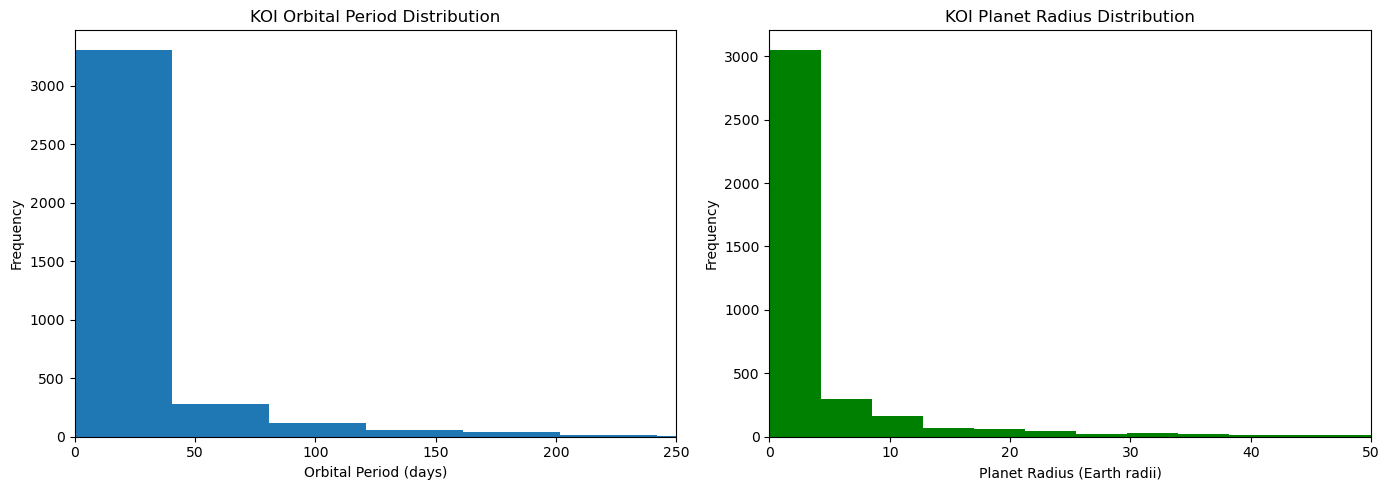

In [29]:
# plots of orbital period and radius to see potential limitations we can place:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# orbital period
koi_df['koi_period'].plot.hist(ax=axes[0], bins=50)
axes[0].set_xlabel("Orbital Period (days)")
axes[0].set_xlim(0, 250)
axes[0].set_title("KOI Orbital Period Distribution")

# exoplanet radius
koi_df['koi_prad'].plot.hist(ax=axes[1], bins=50, color='green')
axes[1].set_xlabel("Planet Radius (Earth radii)")
axes[1].set_xlim(0, 50)
axes[1].set_title("KOI Planet Radius Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# BATMAN PURELY SYNTHETIC DATA
'''
In Isabella_Data_Cleaning, I have inject_batman which outputs our existing lightcurve with injected transit
(basically this is for simulating a planet on real and noisy data)-> I haven't implemented this in the combined version yet

Below is a synthetic generator that creates purely synthetic data from scratch

'''
import batman
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 1000)  # 10 days, 1000 points

# transit parameters (right now they're the basic ones from (https://lkreidberg.github.io/batman/docs/html/tutorial.html#initializing-the-model)
params = batman.TransitParams()       # object to store transit parameters
params.t0 = 0.                        # time of inferior conjunction
params.per = 1.                       # orbital period
params.rp = 0.1                       # planet radius (in units of stellar radii)
params.a = 15.                        # semi-major axis (in units of stellar radii)
params.inc = 87.                      # orbital inclination (in degrees)
params.ecc = 0.                       # eccentricity
params.w = 90.                        # longitude of periastron (in degrees)
params.limb_dark = "nonlinear"        # limb darkening model
params.u = [0.5, 0.1, 0.1, -0.1]      # limb darkening coefficients [u1, u2, u3, u4]

# generate Model
m = batman.TransitModel(params, t) 
flux = m.light_curve(params) # calculates light curve

# Gaussian noise
flux_noisy = flux + np.random.normal(0, 0.0005, size=flux.shape)

# plotting:
plt.figure(figsize=(10,6))
plt.plot(t, flux_noisy, '.', label='Synthetic Data')
plt.plot(t, flux, '-', label='Model')
plt.xlabel('Time [days]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.show()

In [ ]:
# 2) selecting out positives/negatives
positives = koi_df[koi_df["koi_disposition"] == "CONFIRMED"].sample(samples, random_state=42)
negatives = koi_df[koi_df["koi_disposition"] == "FALSE POSITIVE"].sample(samples, random_state=42)

# optionally inject transits into negatives
negatives = negatives.assign(label=0, inject=inject_transit)
positives = positives.assign(label=1, inject=False)
# full df includes both
full_set = pd.concat([positives, negatives], ignore_index=True)
full_set.reset_index(drop=True, inplace=True)

In [ ]:
# 3) transit injection (using a box model)

def inject_box_transit(lc, epoch, period, duration_days, depth):
    """
    Injects a simple box-shaped transit into a LightCurve object
    Arguments:
        lc: LightCurve object
        epoch, period, duration_days: transit parameters
        depth: fractional depth (e.g., 0.01 = 1%)
    Returns:
        New LightCurve with the transit injected
    """
    time = lc.time.value
    flux = lc.flux.copy()
    phase = ((time - epoch + 0.5 * period) % period) - 0.5 * period
    intransit = np.abs(phase) < (duration_days / 2.0)
    flux_inj = flux * (1.0 - depth * intransit.astype(float))
    return LightCurve(time=time, flux=flux_inj, flux_err=getattr(lc, 'flux_err', None))

In [ ]:
# 4) feature extraction for Bayesian model
def compute_basic_features(lc, min_period=0.5, max_period=30.0):
    """
    extracts BLS period/power, SNR, depth, and flux scatter (sigma) from lightcurve
    Args:
        lc: LightCurve object
    Returns:
        Dict with keys: sigma, depth, snr, bls_period, bls_power
    """
    t = lc.time.value
    y = lc.flux.value
    # noise estimate
    sigma = np.nanstd(y)
    # depth estimate -> note: real transit depth is more complex so we might need to look at this a little bit more
    depth_est = np.nanmedian(y) - np.nanmin(y)
    snr = depth_est / sigma if sigma > 0 else 0.0
    
    # BLS
    try:
        bls = BoxLeastSquares(t, y)
        periods = np.linspace(min_period, max_period, 2000)
        durations = np.linspace(0.01, 0.5, 10)
        res = bls.autopower(durations, minimum_period=min_period, maximum_period=max_period)
        idx = np.nanargmax(res.power)
        best_period = res.period[idx]
        best_power = res.power[idx]
    except Exception:
        best_period = np.nan
        best_power = np.nan
    return {'sigma': sigma, 'depth': depth_est, 'snr': snr,'bls_period': best_period, 'bls_power': best_power}

In [ ]:
# 5) preprocessing per star
def process_one_star(row):
    """
    Main function to process a single row/star:
        - Downloads lightcurve
        - (Optionally) injects box transit (for negatives)
        - Interpolates/normalizes flux for CNN input
        - Extracts features for Bayesian/classical models
    Returns None if lightcurve cannot be processed
    """
    kic = int(row["kepid"])
    label = row["label"]
    inject = row["inject"]
    # Use KOI-provided period/start/duration if present, else reasonable defaults
    period = row.get("koi_period", 5.0)
    duration = row.get("koi_duration", 0.3)
    epoch = row.get("koi_time0bk", None)
    try:
        # searching for all Kepler lightcurves
        srch = search_lightcurve(f"KIC {kic}", mission="Kepler")
        if len(srch) == 0:
            return None
        # use either just first quarter (single_quarter) or all available data
        if single_quarter:
            lc = srch[0].download().normalize()
        else:
            lcall = srch.download_all()
            if lcall is None:
                return None
            lc = lcall.stitch().normalize()
        # clean, flatten, reject outliers
        lc = lc.remove_nans().flatten(window_length=901).remove_outliers(sigma=5)
        # inject transit
        if inject_transit:
            # Fill in missing values with defaults
            use_period = period if not pd.isnull(period) else 5.0
            use_duration = duration if not pd.isnull(duration) else 0.3
            use_epoch = epoch if not pd.isnull(epoch) else lc.time.value[0]
            lc = inject_box_transit(lc, use_epoch, use_period, use_duration, depth=0.01)
        # CNN input: fixed-length, normalized array
        flux = lc.flux.value
        x = np.linspace(0, 1, len(flux))
        x_fixed = np.linspace(0, 1, CNN_input_size)
        flux_interp = interp1d(x, flux, kind='linear', fill_value="extrapolate")(x_fixed)
        # normalize (zero mean, unit variance)
        flux_interp = (flux_interp - np.nanmean(flux_interp)) / (np.nanstd(flux_interp)+1e-12)
        # extract features for Bayesian/classical models
        features = compute_basic_features(lc)
        features['kic'] = kic
        features['label'] = label
        features['period'] = period
        features['duration'] = duration
        return {'flux': flux_interp, 'features': features}
    except Exception:
        return None

In [ ]:
# plots of orbital period and radius to see potential limitations we can place:

# orbital period:
ax1 = period.plot.hist()
ax1.set_xlabel("Orbital Period (days)")
ax1.set_xlim(0, 100) 

In [ ]:
# 6) batched processing, multithreading, and checkpoint saving
def process_batches(full_set, OUTDIR, start_batch=0):
    """
    Processes all stars in batches for robustness and speed:
        - Multithreaded for faster lightcurve downloads/processing
        - Each batch saved independently (CNN input, features, labels)
        - All batches merged into master arrays once finished
        - Resumes processing if interrupted (using 'start_batch')
    """
    total = len(full_set)
    for start in range(start_batch * batch_size, total, batch_size):
        end = min(start + batch_size, total)
        this_batch = full_set.iloc[start:end]
        results = []
        with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as executor:
            fut_to_idx = {executor.submit(process_one_star, row): idx for idx, row in this_batch.iterrows()}
            for fut in tqdm(concurrent.futures.as_completed(fut_to_idx), total=len(fut_to_idx), desc=f"Batch {start//batch_size}"):
                res = fut.result()
                if res is not None:
                    results.append(res)
        if not results:
            print(f"Batch {start // batch_size} had no good stars.")
            continue
        # save checkpoint (per batch)
        X_batch = np.stack([r['flux'] for r in results])
        features_batch = pd.DataFrame([r['features'] for r in results])
        y_batch = features_batch["label"].values
        np.save(os.path.join(OUTDIR, f"batch_{start//batch_size}_X.npy"), X_batch)
        np.save(os.path.join(OUTDIR, f"batch_{start//batch_size}_y.npy"), y_batch)
        features_batch.to_csv(os.path.join(OUTDIR, f"batch_{start//batch_size}_features.csv"), index=False)
        print(f"Saved batch {start//batch_size}: {len(X_batch)} stars")

    # after batching, merge all intermediate batch data
    X_files = sorted(glob.glob(os.path.join(OUTDIR, "batch_*_X.npy")))
    y_files = sorted(glob.glob(os.path.join(OUTDIR, "batch_*_y.npy")))
    features_files = sorted(glob.glob(os.path.join(OUTDIR, "batch_*_features.csv")))
    X_full = np.concatenate([np.load(f) for f in X_files])
    y_full = np.concatenate([np.load(f) for f in y_files])
    features_full = pd.concat([pd.read_csv(f) for f in features_files], ignore_index=True)
    np.save(os.path.join(OUTDIR, "X_CNN.npy"), X_full)
    np.save(os.path.join(OUTDIR, "y_CNN.npy"), y_full)
    features_full.to_csv(os.path.join(OUTDIR, "features_all.csv"), index=False)
    print("All batches merged and saved. Pipeline complete.")

In [ ]:
# 7) main execution block: this is what launches our pipeline
if __name__ == "__main__":
    # resume: count existing batch files and continue where left off
    done_batches = len(glob.glob(os.path.join(OUTDIR, "batch_*_X.npy")))
    print(f"Resuming from batch {done_batches}.")
    process_batches(full_set, OUTDIR, start_batch=done_batches)
    print("DONE.")